# Khởi động & Kiểm tra Thuật toán (Synthetic Data)

> **Lưu ý quan trọng**: Đây là notebook DUY NHẤT sử dụng dữ liệu giả (synthetic data). Mục đích của notebook này chỉ là để xác minh (validate) tính đúng đắn của các thuật toán CP-ALS và CP-OPT được cài đặt từ đầu bằng NumPy, đảm bảo chúng có thể khôi phục lại các factor matrices đã biết.

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt

from src.cp_als import cp_als, reconstruct
from src.cp_opt import cp_opt
from src.evaluate import relative_error, factor_similarity

## 1. Tính Robustness: FMS vs Noise Level

Tạo tensor rank 3. Quét qua nhiều mức độ nhiễu khác nhau, chạy CP-ALS và tính Factor Match Score (FMS) so với ground truth `true_factors`.

Evaluating noise robustness...


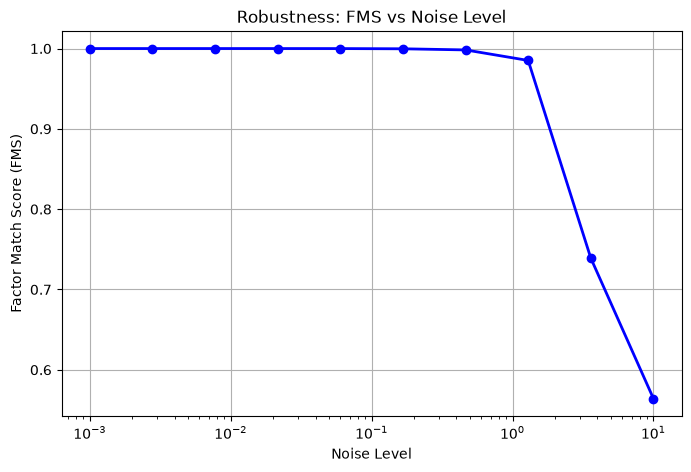

In [2]:
np.random.seed(42)
shape = (10, 15, 20)
true_rank = 3
true_factors = [np.random.randn(s, true_rank) for s in shape]
X_true = reconstruct(true_factors)

noise_levels = np.logspace(-3, 1, 10)
fms_scores = []

print("Evaluating noise robustness...")
for noise in noise_levels:
    E = np.random.randn(*shape)
    X_noisy = X_true + noise * E
    
    w_als, factors_als, cp_info_als = cp_als(X_noisy, rank=true_rank, max_iter=100, tol=1e-6, init='svd')
    f0_als, f1_als, f2_als = factors_als
    
    # Compare recovered factors against true_factors (ground truth)
    _, mean_sim, _ = factor_similarity(true_factors, factors_als, greedy_permutation=True)
    fms_scores.append(mean_sim)

plt.figure(figsize=(8, 5))
plt.semilogx(noise_levels, fms_scores, 'bo-', linewidth=2)
plt.xlabel('Noise Level')
plt.ylabel('Factor Match Score (FMS)')
plt.title('Robustness: FMS vs Noise Level')
plt.grid(True)
plt.show()

## 2. Lựa chọn Rank (Elbow Plot) & So sánh CP-ALS vs CP-OPT

Cố định mức nhiễu nhỏ. Quét qua các rank từ 1 đến 8, chạy cả CP-ALS và CP-OPT để vẽ đường cong Reconstruction Error vs Rank (elbow plot).

Evaluating ranks...


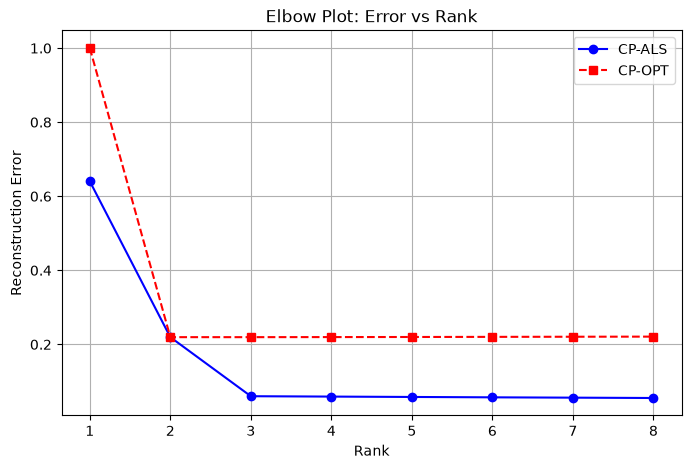

In [3]:
np.random.seed(123)
X_test = X_true + 0.1 * np.random.randn(*shape)
ranks = list(range(1, 9))
errs_als = []
errs_opt = []

print("Evaluating ranks...")
for r in ranks:
    w_als, factors_als, cp_info_als = cp_als(X_test, rank=r, max_iter=100, tol=1e-6, init='svd')
    X_hat_als = reconstruct(factors_als, w_als)
    errs_als.append(relative_error(X_test, X_hat_als))
    
    w_opt, f_opt, info_opt = cp_opt(X_test, rank=r, max_iter=100, tol=1e-6, init='svd')
    if not info_opt.get('converged', True):
        print(f"Warning: CP-OPT did not converge for rank {r}")
    X_hat_opt = reconstruct(f_opt, w_opt)
    errs_opt.append(relative_error(X_test, X_hat_opt))

plt.figure(figsize=(8, 5))
plt.plot(ranks, errs_als, 'bo-', label='CP-ALS')
plt.plot(ranks, errs_opt, 'rs--', label='CP-OPT')
plt.xlabel('Rank')
plt.ylabel('Reconstruction Error')
plt.title('Elbow Plot: Error vs Rank')
plt.legend()
plt.grid(True)
plt.show()